**Diabetes Risk Prediction**  
This notebook cleans the data to prepare it for our model that predicts Low /Moderate / High diabetes risk.

**Step 1: Import Libraries**

In [28]:
## Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE

print("Libraries loaded!")

Libraries loaded!


**Step 2: Import Data File**

In [27]:
# The dataset is loaded directly from our Github repository, so no one has to upload the file from a local drive.

url = "https://raw.githubusercontent.com/cano-elda/Midterm-Diabetes-Risk-Prediction-Group-3-ITAI-1371/refs/heads/main/data/diabetes_risk.csv"
df = pd.read_csv(url)
print("Data loaded!")


Data loaded!


**Step 3: Initial Analysis of Data**

In [26]:
# Print rows and columns

print("Rows and columns", df.shape)
df.head(10)
df.info()
df.isnull().sum()
df.describe()
df["diabetes_risk"].value_counts()


Rows and columns (6870, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6870 entries, 0 to 6869
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                6870 non-null   int64  
 1   age                       6870 non-null   int64  
 2   gender                    6870 non-null   object 
 3   city                      6870 non-null   object 
 4   bmi                       6870 non-null   float64
 5   family_history_diabetes   6870 non-null   object 
 6   physical_activity_level   6870 non-null   object 
 7   diet_type                 6870 non-null   object 
 8   smoking_status            6649 non-null   object 
 9   alcohol_consumption       5115 non-null   object 
 10  hours_sleep_per_night     6870 non-null   float64
 11  stress_level              6870 non-null   int64  
 12  fasting_blood_sugar       6870 non-null   int64  
 13  hba1c_level               6870 non-

,count
diabetes_risk,
Low,4033
Moderate,1751
High,1086


**Step 4: Split Data: 70% Training / 30% Testing**

In [29]:
# Split data into 70% training and 30% testing

train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df["diabetes_risk"])
train = train.copy()
test = test.copy()

print("Training set:", train.shape)
print("Testing set:", test.shape)
print("Training classes:", train["diabetes_risk"].value_counts().to_dict())
print("Testing classes: ", test["diabetes_risk"].value_counts().to_dict())
train.head()



Training set: (4809, 19)
Testing set: (2061, 19)
Training classes: {'Low': 2823, 'Moderate': 1226, 'High': 760}
Testing classes:  {'Low': 1210, 'Moderate': 525, 'High': 326}


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
6150,13387,59,Male,Chennai,27.3,Yes,Sedentary,Vegetarian,Never,Never,8.0,8,304,9.3,150,76,112.9,High,High
2927,6402,42,Female,Delhi,22.1,No,Active,Non-Vegetarian,Never,Never,6.9,7,111,6.1,150,91,96.2,High,Low
5296,11480,36,Female,Bengaluru,19.5,Yes,Sedentary,Non-Vegetarian,Former,NaN,8.0,5,117,5.8,121,82,87.1,High,Low
437,919,53,Female,Bengaluru,16.2,No,Active,Non-Vegetarian,Never,NaN,8.2,7,179,7.3,160,94,82.6,Low,Low
1341,2867,54,Female,Hyderabad,21.1,No,Moderate,Non-Vegetarian,Former,Never,9.5,4,147,6.7,152,90,96.1,NaN,Low


**Step 5: Basic Cleaning**  

This step removes the "patient_id colunm because this information does not any valued to the dataset and to results we are looking for. It also removes 2 impossible rows. Since we split the data before any clean up we have to do it to the training and testing set but this does not create any leak into the testing set.

In [30]:
# Remove the patient_id column and 2 impossible rows.

for data in [train, test]:
  data.drop(columns=["patient_id"], inplace=True)

print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

bad_train = train["blood_pressure_diastolic"] >= train["blood_pressure_systolic"]
bad_test = test["blood_pressure_diastolic"] >= test["blood_pressure_systolic"]
print("Bad rows in train:", bad_train.sum())
print("Bad rows in test:", bad_test.sum())

train = train[~(bad_train)]
test = test[~(bad_test)]

print("Training set after cleaning:", train.shape)
print("Testing set after cleaning:", test.shape)


Duplicate rows in train: 0
Duplicate rows in test: 0
Bad rows in train: 2
Bad rows in test: 0
Training set after cleaning: (4807, 18)
Testing set after cleaning: (2061, 18)


**Step 6: EDA Charts on Training Data Before Processing**

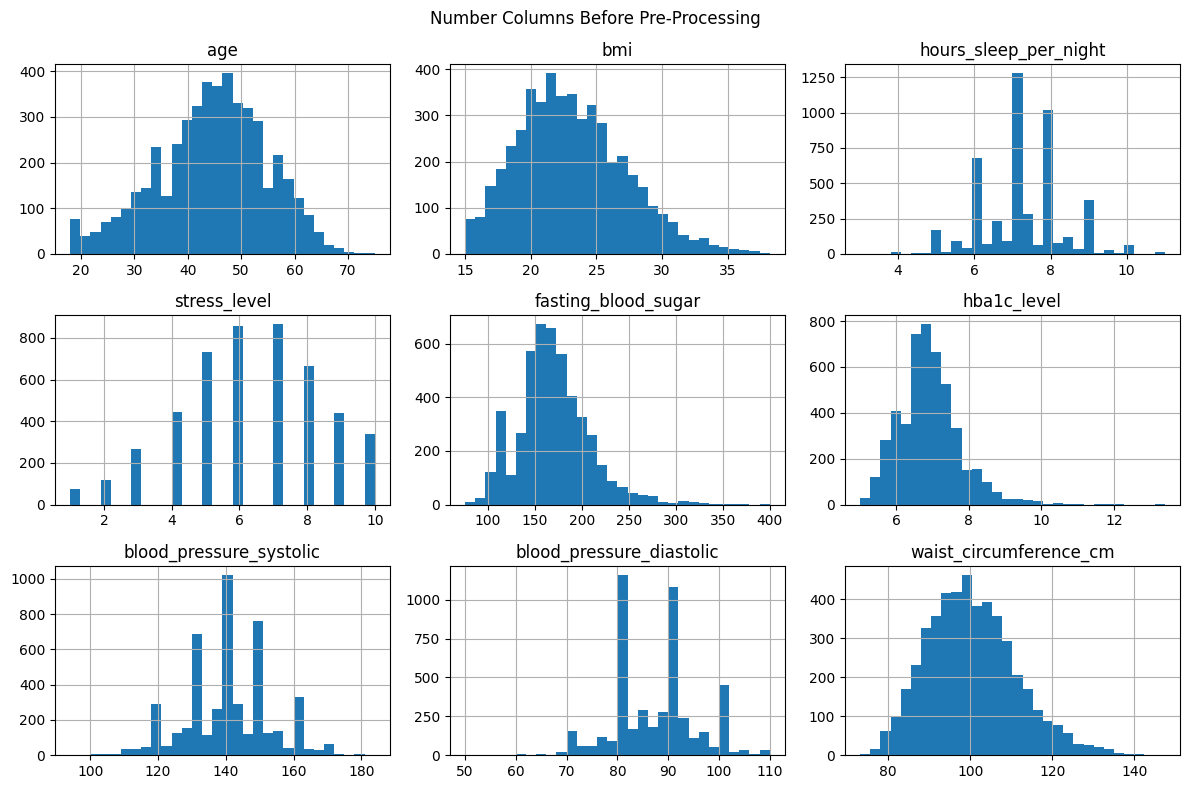

age                        -0.307296
bmi                         0.491386
hours_sleep_per_night       0.076439
stress_level               -0.221471
fasting_blood_sugar         0.929281
hba1c_level                 0.957686
blood_pressure_systolic    -0.011257
blood_pressure_diastolic    0.073561
waist_circumference_cm      0.487015
dtype: float64


In [36]:
# Charts before Data Was Processed

train.hist(figsize=(12, 8), bins=30)
plt.suptitle("Number Columns Before Pre-Processing")
plt.tight_layout()
plt.show()
print(train.skew(numeric_only=True))


This is a histogram of all the columns or features in the dataset before processing. As noticed some of the features have negative values, this mean they are skewed and will need to be looked at to see if they need to be fix.

**Step 7: Fill Nan and Null Values**

In [37]:
# Fill in empty colums

missing_before = train.isnull().sum()

smoke_mode = train["smoking_status"].mode()[0]
income_mode = train["income_bracket"].mode()[0]
print("Smoking mode:", smoke_mode, " Income mode:", income_mode)

for data in [train, test]:
  data["smoking_status"] = data["smoking_status"].fillna(smoke_mode)
  data["income_bracket"] = data["income_bracket"].fillna(income_mode)
  data["alcohol_consumption"] = data["alcohol_consumption"].fillna("Unknown")

print("Missing values left in train:", train.isnull().sum().sum())
print("Missing values left in test:", test.isnull().sum().sum())

Smoking mode: Never  Income mode: Middle
Missing values left in train: 0
Missing values left in test: 0


**Before/After Chart**

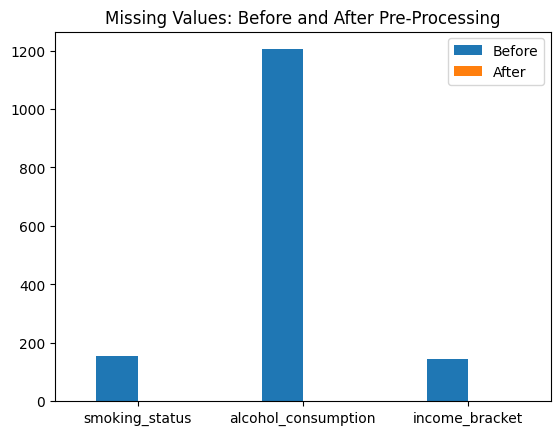

In [38]:
# Chart Showing The Changes

compare = pd.DataFrame({"Before": missing_before, "After": train.isnull().sum()})
compare = compare[compare["Before"] > 0]
compare.plot(kind="bar")
plt.title("Missing Values: Before and After Pre-Processing")
plt.xticks(rotation=0)
plt.show()